In [1]:
import sys
from pathlib import Path
 
cwd  = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from itertools import product
from tqdm import tqdm
 
from src.utils.plotting import set_style, FigureManager
from src.utils.config import load_config
 
set_style()
 
cfg    = load_config(str(ROOT / "config/quadcopter_path_following_circle.yaml"))
fm     = FigureManager(cfg, base_dir=ROOT)

In [2]:
R   = 3.0    # circle radius [m]
Z_D = 3.0    # target altitude [m]
DT  = 0.005  # timestep [s]
T   = 60.0   # simulation length [s]
 
# position and yaw gains (kinematic level)
KX, KY, KZ, KPSI = 2.0, 2.0, 2.0, 2.0
 
def _wrap(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

In [3]:
def sim_trajectory_tracking(x0, y0, z0, omega, *, dt=DT, T=T) -> pd.DataFrame:
    """
    Kinematic trajectory tracking.
    Reference: p_d(t) = [R cosωt, R sinωt, Z_D] — moves at fixed speed ω.
    """
    N = int(T / dt)
    x, y, z, yaw = x0, y0, z0, 0.0
    rows = []
 
    for i in range(N):
        t   = i * dt
        xd  =  R * np.cos(omega * t)
        yd  =  R * np.sin(omega * t)
        vxd = -R * omega * np.sin(omega * t)
        vyd =  R * omega * np.cos(omega * t)
        psi_d = _wrap(omega * t + np.pi / 2)
 
        ex = x - xd;  ey = y - yd;  ez = z - Z_D
        e_psi = _wrap(yaw - psi_d)
 
        vx   = vxd - KX   * ex
        vy   = vyd - KY   * ey
        vz   =     - KZ   * ez
        wpsi = omega - KPSI * e_psi
 
        x += vx * dt;  y += vy * dt;  z += vz * dt
        yaw = _wrap(yaw + wpsi * dt)
 
        rows.append(dict(t=t, x=x, y=y, z=z,
                         ex=ex, ey=ey, ez=ez,
                         e_norm=np.sqrt(ex**2 + ey**2 + ez**2)))
 
    return pd.DataFrame(rows)
 

In [4]:
def sim_path_following(x0, y0, z0, v_d, k_gamma, *, dt=DT, T=T) -> pd.DataFrame:
    """
    Kinematic path following.
    Reference: p_d(γ) = [R cosγ, R sinγ, Z_D] with γ̇ = v_d(1 + k_γ e_s).
    γ initialised to the closest point on the circle.
    """
    N     = int(T / dt)
    x, y, z, yaw = x0, y0, z0, 0.0
    gamma = np.arctan2(y0, x0)          # closest angle on circle in xy
    rows  = []
 
    for i in range(N):
        t = i * dt
 
        xd  = R * np.cos(gamma);  yd = R * np.sin(gamma)
        tx  = -np.sin(gamma);     ty = np.cos(gamma)   # unit tangent
 
        ex  = x - xd;  ey = y - yd;  ez = z - Z_D
        e_s = tx * ex + ty * ey                         # along-track error
 
        gamma_dot = v_d * (1.0 + k_gamma * e_s)
 
        vx   = -R * np.sin(gamma) * gamma_dot - KX   * ex
        vy   =  R * np.cos(gamma) * gamma_dot - KY   * ey
        vz   =                                 -KZ   * ez
        psi_d = _wrap(gamma + np.pi / 2)
        wpsi  = gamma_dot - KPSI * _wrap(yaw - psi_d)
 
        x += vx * dt;  y += vy * dt;  z += vz * dt
        yaw   = _wrap(yaw + wpsi * dt)
        gamma = gamma + gamma_dot * dt
 
        rows.append(dict(t=t, x=x, y=y, z=z,
                         ex=ex, ey=ey, ez=ez,
                         e_norm=np.sqrt(ex**2 + ey**2 + ez**2),
                         gamma_dot=gamma_dot, e_s=e_s))
 
    return pd.DataFrame(rows)

In [8]:
def metrics(df: pd.DataFrame, t_transient: float = 10.0) -> dict:
    """Scalar summary metrics for one simulation run."""
    t = df["t"].values
    en = df["e_norm"].values
    ss = df["t"] >= t_transient

    return {
        "integral_error": float(np.trapezoid(en, t)),
        "peak_error": float(en.max()),
        "ss_rms": (
            float(np.sqrt((df.loc[ss, "e_norm"] ** 2).mean()))
            if ss.any()
            else np.nan
        ),
        "conv_time": (
            float(df.loc[df["e_norm"] < 0.15, "t"].min())
            if (df["e_norm"] < 0.15).any()
            else np.nan
        ),
    }
 

Speed sweep: 100%|██████████| 7/7 [00:00<00:00, 13.48it/s]


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study1_speed_sweep.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study1_speed_sweep.png


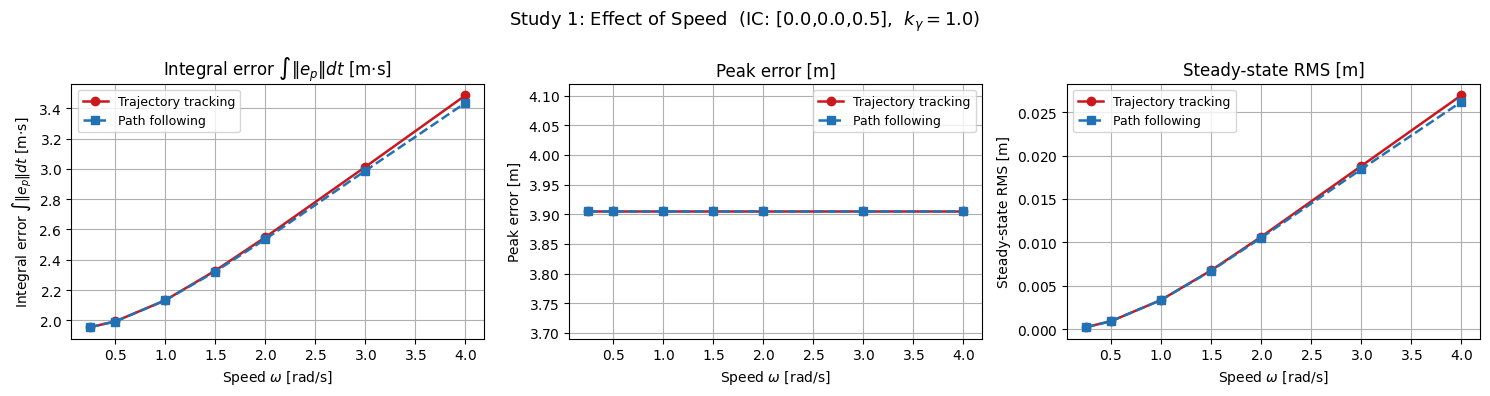


Integral error ratio PF/TT  (<1 = PF better):
omega
0.25    0.999975
0.50    0.999913
1.00    0.999659
1.50    0.997496
2.00    0.994973
3.00    0.991447
4.00    0.985778

Crossover speed: ω ≈ nan rad/s


In [9]:
# ── cell: study 1 — effect of speed ──────────────────────────────────────────
r"""
## Study 1 — Effect of Speed
 
Fix initial condition at [0, 0, 0.5] (inside circle, below target altitude).
Sweep ω = v_d ∈ {0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0} rad/s.
 
Question: at what speed does path following stop being better than trajectory
tracking?
"""
 
speeds  = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
K_GAMMA = 1.0   # fixed k_gamma for this study
X0, Y0, Z0 = 0.0, 0.0, 0.5
 
speed_results = []
for omega in tqdm(speeds, desc="Speed sweep"):
    df_tt = sim_trajectory_tracking(X0, Y0, Z0, omega)
    df_pf = sim_path_following(X0, Y0, Z0, omega, K_GAMMA)
    m_tt  = metrics(df_tt);  m_tt["method"] = "TT";  m_tt["omega"] = omega
    m_pf  = metrics(df_pf);  m_pf["method"] = "PF";  m_pf["omega"] = omega
    speed_results += [m_tt, m_pf]
 
df_speed = pd.DataFrame(speed_results)
 
fig_s, axs = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = [
    ("integral_error", "Integral error $\\int\\|e_p\\|dt$ [m·s]"),
    ("peak_error",     "Peak error [m]"),
    ("ss_rms",         "Steady-state RMS [m]"),
]
 
for ax, (m, lbl) in zip(axs, metrics_to_plot):
    tt = df_speed[df_speed["method"] == "TT"]
    pf = df_speed[df_speed["method"] == "PF"]
    ax.plot(tt["omega"], tt[m], "o-", color="#cb181d",
            linewidth=1.8, label="Trajectory tracking")
    ax.plot(pf["omega"], pf[m], "s--", color="#2171b5",
            linewidth=1.8, label="Path following")
    ax.set_xlabel(r"Speed $\omega$ [rad/s]"); ax.set_ylabel(lbl)
    ax.set_title(lbl); ax.legend(fontsize=9); ax.grid()
 
fig_s.suptitle(
    f"Study 1: Effect of Speed  (IC: [{X0},{Y0},{Z0}],  $k_\\gamma={K_GAMMA}$)",
    fontsize=13)
fig_s.tight_layout()
fm.save_and_show(fig_s, "study1_speed_sweep")
 
# crossover speed
ratio = df_speed.pivot(index="omega", columns="method", values="integral_error")
ratio["PF_vs_TT"] = ratio["PF"] / ratio["TT"]
print("\nIntegral error ratio PF/TT  (<1 = PF better):")
print(ratio["PF_vs_TT"].to_string())
crossover = ratio.loc[ratio["PF_vs_TT"] > 1.0].index.min()
print(f"\nCrossover speed: ω ≈ {crossover} rad/s")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study2_initial_conditions.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study2_initial_conditions.png


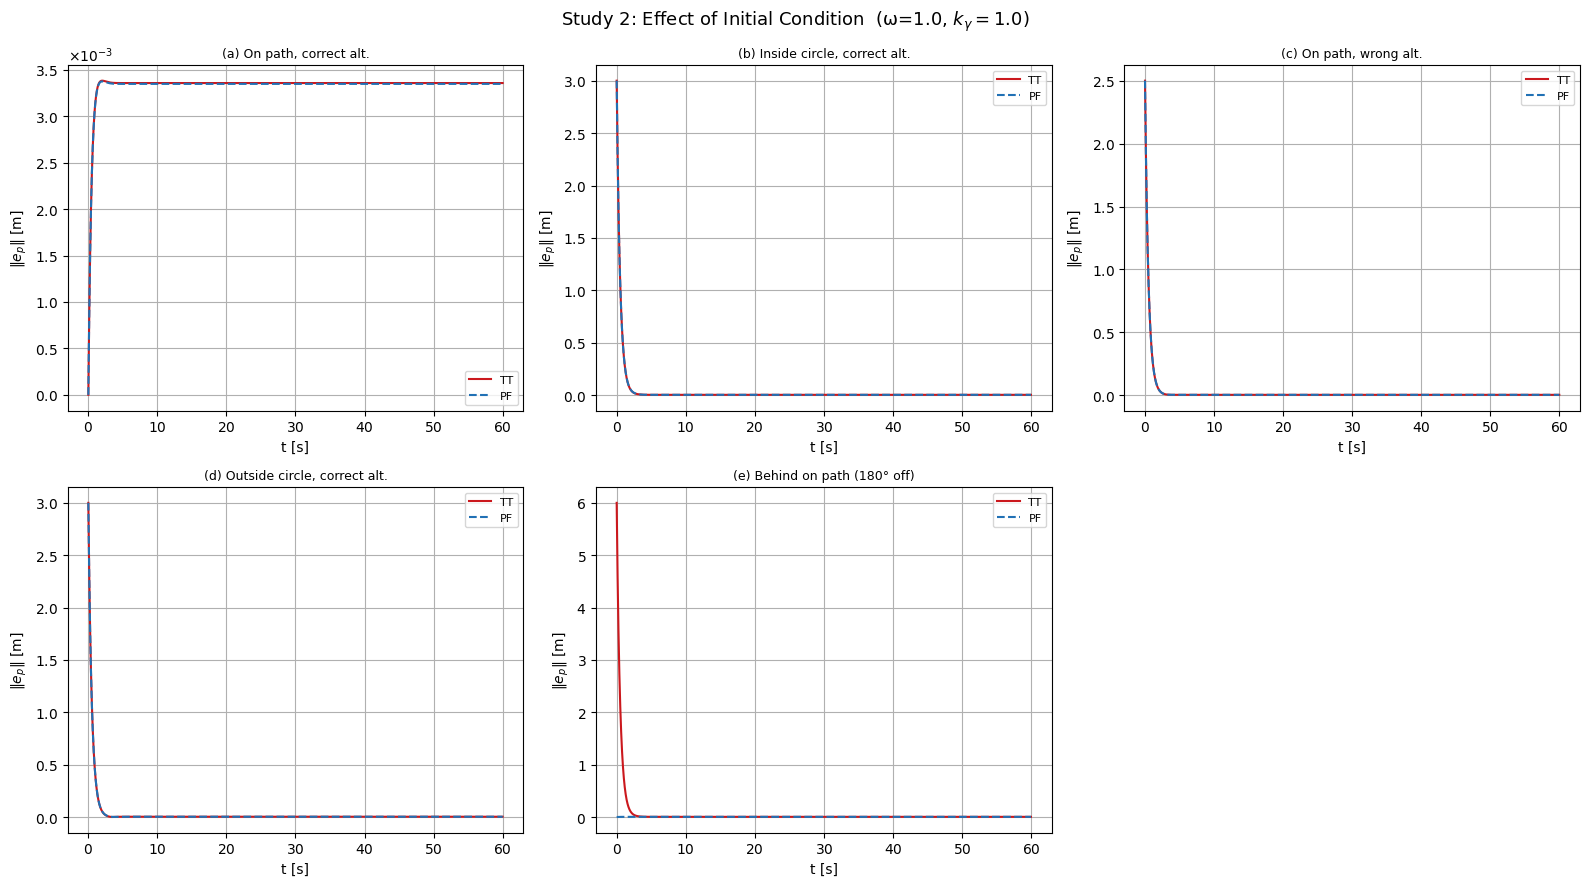


Integral error — PF vs TT by initial condition:
method                                  PF        TT     PF/TT winner
ic                                                                   
(a) On path, correct alt.         0.199627  0.200158  0.997346   PF ✓
(b) Inside circle, correct alt.   1.681189  1.681904  0.999575   PF ✓
(c) On path, wrong alt.           1.433110  1.433624  0.999641   PF ✓
(d) Outside circle, correct alt.  1.681076  1.680726  1.000208   TT ✓
(e) Behind on path (180° off)     0.199627  3.174103  0.062892   PF ✓


In [10]:
r"""
## Study 2 — Effect of Initial Condition
 
Fix ω = 1.0 rad/s, k_γ = 1.0.
Vary the initial position across four qualitatively different cases:
 
  (a) On path, correct altitude     → both should be identical
  (b) Inside circle, correct alt.   → large cross-track error, no along-track
  (c) On path, wrong altitude       → altitude error only
  (d) Outside circle, correct alt.  → cross-track error (different sign)
  (e) Behind on path (φ offset)     → large along-track error
 
Path following is expected to excel in cases (b) and (d): when the vehicle
must first converge to the path before moving along it.
Trajectory tracking may be better in case (e): when the reference is "ahead"
and provides a natural pull.
"""
 
OMEGA_2 = 1.0
K_GAMMA_2 = 1.0
 
ics = {
    "(a) On path, correct alt.":      (R, 0.0,  Z_D),
    "(b) Inside circle, correct alt.": (0.0, 0.0, Z_D),
    "(c) On path, wrong alt.":        (R, 0.0,  0.5),
    "(d) Outside circle, correct alt.":(R+3, 0.0, Z_D),
    "(e) Behind on path (180° off)":  (-R, 0.0, Z_D),
}
 
fig_ic, axs = plt.subplots(2, 3, figsize=(16, 9))
axs_flat = axs.flat
 
ic_results = []
for (label, (x0, y0, z0)), ax in zip(ics.items(), axs_flat):
    df_tt = sim_trajectory_tracking(x0, y0, z0, OMEGA_2)
    df_pf = sim_path_following(x0, y0, z0, OMEGA_2, K_GAMMA_2)
 
    ax.plot(df_tt["t"], df_tt["e_norm"], color="#cb181d",
            linewidth=1.5, label="TT")
    ax.plot(df_pf["t"], df_pf["e_norm"], color="#2171b5",
            linewidth=1.5, linestyle="--", label="PF")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("t [s]"); ax.set_ylabel(r"$\|e_p\|$ [m]")
    ax.legend(fontsize=8); ax.grid()
 
    m_tt = metrics(df_tt); m_tt.update({"method":"TT","ic":label,"x0":x0,"y0":y0,"z0":z0})
    m_pf = metrics(df_pf); m_pf.update({"method":"PF","ic":label,"x0":x0,"y0":y0,"z0":z0})
    ic_results += [m_tt, m_pf]
 
axs_flat[-1].set_visible(False)  # hide last empty subplot
 
fig_ic.suptitle(
    f"Study 2: Effect of Initial Condition  (ω={OMEGA_2}, $k_\\gamma={K_GAMMA_2}$)",
    fontsize=13)
fig_ic.tight_layout()
fm.save_and_show(fig_ic, "study2_initial_conditions")
 
df_ic = pd.DataFrame(ic_results)
print("\nIntegral error — PF vs TT by initial condition:")
piv_ic = df_ic.pivot(index="ic", columns="method", values="integral_error")
piv_ic["PF/TT"] = piv_ic["PF"] / piv_ic["TT"]
piv_ic["winner"] = piv_ic["PF/TT"].apply(lambda r: "PF ✓" if r < 1.0 else "TT ✓")
print(piv_ic.to_string())

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study3_k_gamma_sweep.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study3_k_gamma_sweep.png


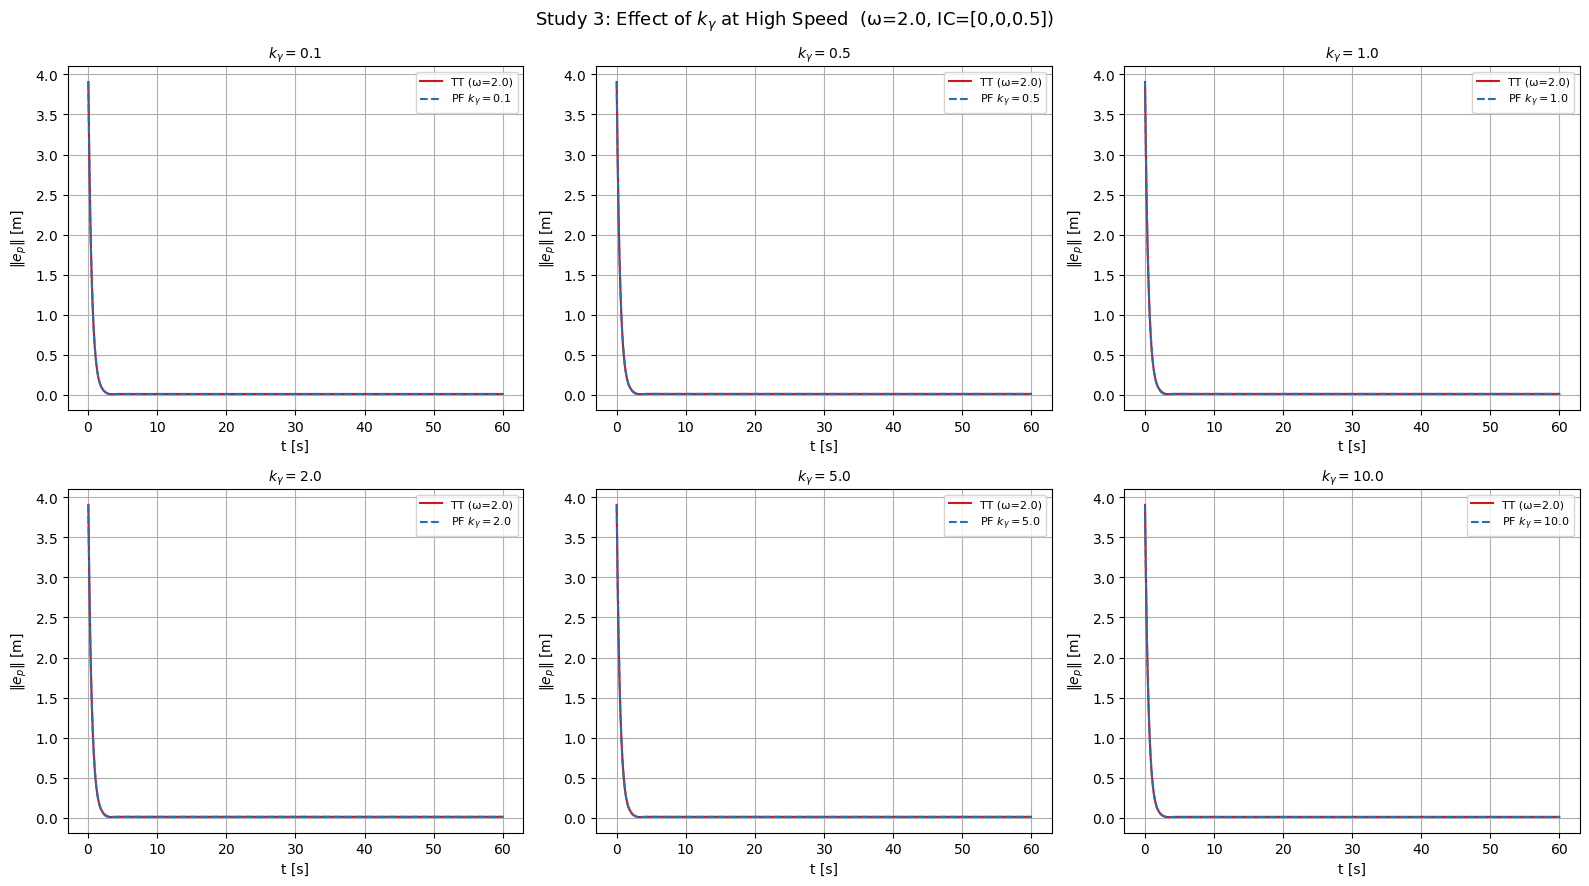


TT integral error = 2.55 m·s
   k_gamma  integral_error  peak_error    ss_rms     PF/TT
0      0.1        2.547153    3.905125  0.010621  0.999472
1      0.5        2.541630    3.905125  0.010574  0.997305
2      1.0        2.535689    3.905125  0.010515  0.994973
3      2.0        2.526927    3.905125  0.010400  0.991536
4      5.0        2.509183    3.905125  0.010077  0.984573
5     10.0        2.485608    3.905125  0.009594  0.975322


In [11]:
r"""
## Study 3 — Effect of k_γ at High Speed
 
Fix ω = 2.0 rad/s, IC = [0, 0, 0.5].
Sweep k_γ ∈ {0.1, 0.5, 1.0, 2.0, 5.0, 10.0}.
 
Path following with multiplicative law: γ̇ = v_d(1 + k_γ e_s).
 
Too small k_γ → virtual target runs away.
Too large k_γ → unstable oscillations in γ.
There is an optimal window.
"""
 
OMEGA_3  = 2.0
K_GAMMAS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
 
fig_kg, axs = plt.subplots(2, 3, figsize=(16, 9))
kg_results  = []
 
df_tt3 = sim_trajectory_tracking(X0, Y0, Z0, OMEGA_3)
 
for (kg, ax) in zip(K_GAMMAS, axs.flat):
    df_pf = sim_path_following(X0, Y0, Z0, OMEGA_3, kg)
 
    ax.plot(df_tt3["t"], df_tt3["e_norm"], color="#cb181d",
            linewidth=1.5, label=f"TT (ω={OMEGA_3})")
    ax.plot(df_pf["t"],  df_pf["e_norm"],  color="#2171b5",
            linewidth=1.5, linestyle="--", label=f"PF $k_\\gamma={kg}$")
    ax.set_title(f"$k_\\gamma = {kg}$", fontsize=10)
    ax.set_xlabel("t [s]"); ax.set_ylabel(r"$\|e_p\|$ [m]")
    ax.legend(fontsize=8); ax.grid()
 
    m = metrics(df_pf); m["k_gamma"] = kg
    kg_results.append(m)
 
fig_kg.suptitle(
    f"Study 3: Effect of $k_\\gamma$ at High Speed  (ω={OMEGA_3}, IC=[0,0,0.5])",
    fontsize=13)
fig_kg.tight_layout()
fm.save_and_show(fig_kg, "study3_k_gamma_sweep")
 
df_kg = pd.DataFrame(kg_results)
tt3_int = metrics(df_tt3)["integral_error"]
df_kg["PF/TT"] = df_kg["integral_error"] / tt3_int
print(f"\nTT integral error = {tt3_int:.2f} m·s")
print(df_kg[["k_gamma","integral_error","peak_error","ss_rms","PF/TT"]].to_string())
 

Feasibility map: 100%|██████████| 144/144 [00:09<00:00, 14.73it/s]


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study4_feasibility_map.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study4_feasibility_map.png


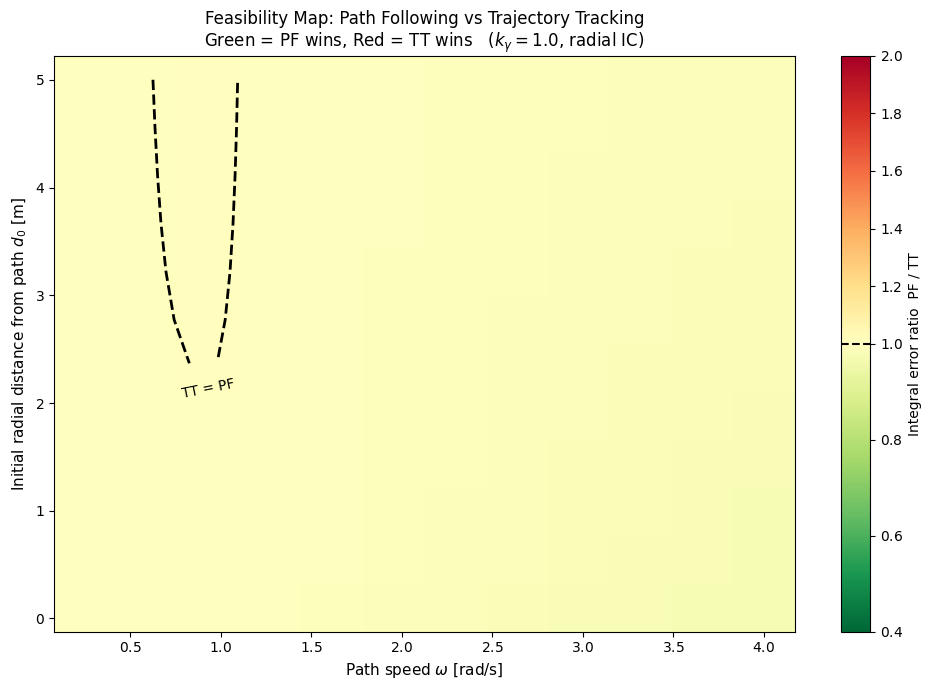

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study4_feasibility_map.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study4_feasibility_map.png')]

In [12]:
# ── cell: study 4 — 2D feasibility map (speed × initial distance) ─────────────
r"""
## Study 4 — Feasibility Map: Speed × Initial Distance
 
2D heatmap: colour = integral error ratio PF/TT.
  Green (<1): path following wins
  Red   (>1): trajectory tracking wins
 
x-axis: speed ω ∈ [0.25, 4.0] rad/s
y-axis: initial distance from circle d₀ ∈ [0.1, 5.0] m
         (vehicle starts at [R + d₀, 0, Z_D] — purely radial offset)
 
k_γ = 1.0 (fixed, representative value).
"""
 
OMEGAS_4  = np.linspace(0.25, 4.0, 12)
DISTS_4   = np.linspace(0.1,  5.0, 12)
K_GAMMA_4 = 1.0
 
ratio_map = np.zeros((len(DISTS_4), len(OMEGAS_4)))
 
for (i, d0), (j, omega) in tqdm(
    list(product(enumerate(DISTS_4), enumerate(OMEGAS_4))),
    desc="Feasibility map",
):
    x0 = R + d0   # radially outside the circle
    df_tt = sim_trajectory_tracking(x0, 0.0, Z_D, omega)
    df_pf = sim_path_following(x0,      0.0, Z_D, omega, K_GAMMA_4)
    ie_tt = metrics(df_tt)["integral_error"]
    ie_pf = metrics(df_pf)["integral_error"]
    ratio_map[i, j] = ie_pf / ie_tt if ie_tt > 0 else np.nan
 
fig_map, ax_map = plt.subplots(figsize=(10, 7))
 
# diverging colormap centred at 1.0
vmin, vmax = 0.4, 2.0
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)
im = ax_map.pcolormesh(OMEGAS_4, DISTS_4, ratio_map,
                        cmap="RdYlGn_r", norm=norm, shading="auto")
 
# contour at ratio = 1 (the decision boundary)
cs = ax_map.contour(OMEGAS_4, DISTS_4, ratio_map, levels=[1.0],
                     colors="black", linewidths=2.0, linestyles="--")
ax_map.clabel(cs, fmt="TT = PF", fontsize=10)
 
cbar = fig_map.colorbar(im, ax=ax_map, label="Integral error ratio  PF / TT")
cbar.ax.axhline(1.0, color="black", linewidth=1.5, linestyle="--")
 
ax_map.set_xlabel(r"Path speed $\omega$ [rad/s]", fontsize=11)
ax_map.set_ylabel(r"Initial radial distance from path $d_0$ [m]", fontsize=11)
ax_map.set_title(
    "Feasibility Map: Path Following vs Trajectory Tracking\n"
    r"Green = PF wins, Red = TT wins   ($k_\gamma = 1.0$, radial IC)",
    fontsize=12,
)
fig_map.tight_layout()
fm.save_and_show(fig_map, "study4_feasibility_map")
 

Optimal k_gamma: 100%|██████████| 5/5 [00:05<00:00,  1.13s/it]



Optimal k_gamma by speed:
   omega  best_k_gamma  best_ratio
0    0.5          10.0    0.998551
1    1.0          10.0    0.995862
2    1.5          10.0    0.987672
3    2.0          10.0    0.975322
4    3.0          10.0    0.942678

Linear fit: k_gamma* ≈ -0.000 * omega + 10.000
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study5_optimal_k_gamma.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study5_optimal_k_gamma.png


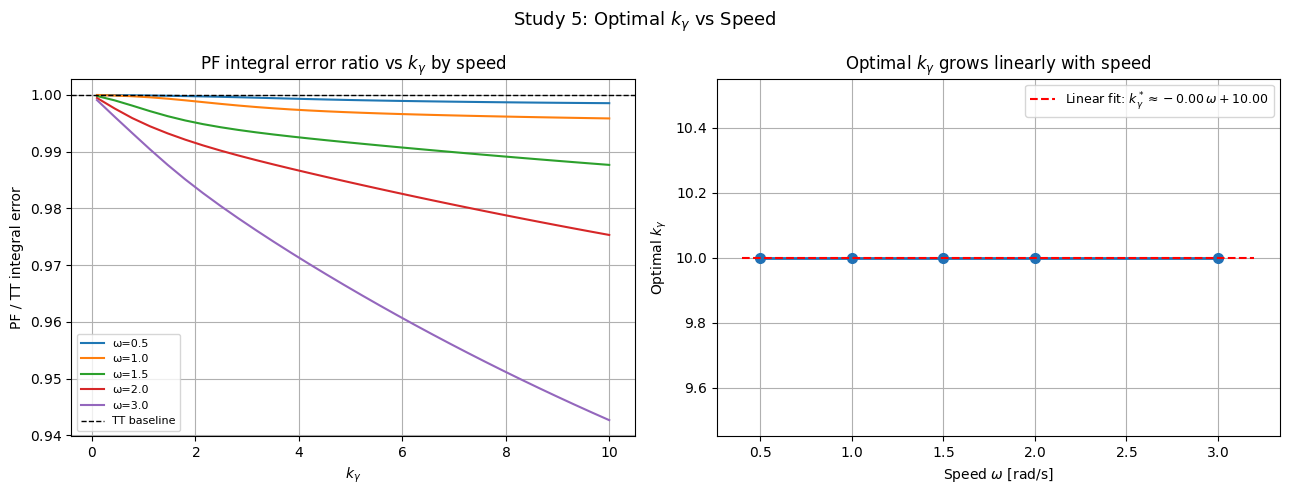

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study5_optimal_k_gamma.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/study5_optimal_k_gamma.png')]

In [13]:
r"""
## Study 5 — Optimal k_γ vs Speed
 
For each speed ω, find the k_γ that minimises the PF integral error.
Shows how k_γ must be tuned with ω.
"""
 
OMEGAS_5  = [0.5, 1.0, 1.5, 2.0, 3.0]
K_GAMMAS5 = np.linspace(0.1, 10.0, 30)
 
fig_opt, axs = plt.subplots(1, 2, figsize=(13, 5))
 
opt_results = []
for omega in tqdm(OMEGAS_5, desc="Optimal k_gamma"):
    df_tt = sim_trajectory_tracking(X0, Y0, Z0, omega)
    tt_ie = metrics(df_tt)["integral_error"]
    ies   = []
    for kg in K_GAMMAS5:
        df_pf = sim_path_following(X0, Y0, Z0, omega, kg)
        ies.append(metrics(df_pf)["integral_error"])
    ies = np.array(ies)
    best_kg  = K_GAMMAS5[np.argmin(ies)]
    best_ie  = ies.min()
    axs[0].plot(K_GAMMAS5, ies / tt_ie, linewidth=1.5, label=f"ω={omega}")
    opt_results.append({"omega": omega, "best_k_gamma": best_kg,
                        "best_PF_ie": best_ie, "TT_ie": tt_ie,
                        "best_ratio": best_ie / tt_ie})
 
axs[0].axhline(1.0, color="black", linewidth=1.0, linestyle="--",
               label="TT baseline")
axs[0].set_xlabel(r"$k_\gamma$"); axs[0].set_ylabel("PF / TT integral error")
axs[0].set_title(r"PF integral error ratio vs $k_\gamma$ by speed")
axs[0].legend(fontsize=8); axs[0].grid()
 
df_opt = pd.DataFrame(opt_results)
axs[1].plot(df_opt["omega"], df_opt["best_k_gamma"],
            "o-", color="#2171b5", linewidth=2.0, markersize=7)
axs[1].set_xlabel(r"Speed $\omega$ [rad/s]")
axs[1].set_ylabel(r"Optimal $k_\gamma$")
axs[1].set_title(r"Optimal $k_\gamma$ grows linearly with speed")
axs[1].grid()
 
# fit a line
coeffs = np.polyfit(df_opt["omega"], df_opt["best_k_gamma"], 1)
omega_line = np.linspace(0.4, 3.2, 100)
axs[1].plot(omega_line, np.polyval(coeffs, omega_line), "r--",
            linewidth=1.5,
            label=f"Linear fit: $k_\\gamma^* \\approx {coeffs[0]:.2f}\\,\\omega + {coeffs[1]:.2f}$")
axs[1].legend(fontsize=9)
 
print("\nOptimal k_gamma by speed:")
print(df_opt[["omega","best_k_gamma","best_ratio"]].to_string())
print(f"\nLinear fit: k_gamma* ≈ {coeffs[0]:.3f} * omega + {coeffs[1]:.3f}")
 
fig_opt.suptitle(r"Study 5: Optimal $k_\gamma$ vs Speed", fontsize=13)
fig_opt.tight_layout()
fm.save_and_show(fig_opt, "study5_optimal_k_gamma")
 